# IoT-23 Dataset Analysis

Goal:
Analyze IoT network traffic and attack behavior from the IoT-23 dataset
to build a Retrieval-Augmented IoT Security Assistant.

Objectives:
- Understand dataset structure
- Identify attack labels
- Extract useful security features
- Convert records into retrievable documents

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
file_path = r"datasets/iot23/CTU-Honeypot-Capture-4-1/bro/conn.log.labeled"

In [4]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
e:\ICOT-RAG\notebooks


In [5]:
file_path = "../datasets/iot23/CTU-Honeypot-Capture-4-1/bro/conn.log.labeled"

In [6]:
rows = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.startswith("#"):

            parts = line.strip().split("\t")

            last_field = parts.pop()

            last_parts = last_field.split()

            parts.extend(last_parts)

            rows.append(parts)

In [7]:
len(rows)

452

In [8]:
rows[0]

['1540469302.538640',
 'CGm6jB4dXK71ZDWUDh',
 '192.168.1.132',
 '58687',
 '216.239.35.4',
 '123',
 'udp',
 '-',
 '0.114184',
 '48',
 '48',
 'SF',
 '-',
 '-',
 '0',
 'Dd',
 '1',
 '76',
 '1',
 '76',
 '-',
 'benign',
 '-']

In [9]:
rows[:5]

[['1540469302.538640',
  'CGm6jB4dXK71ZDWUDh',
  '192.168.1.132',
  '58687',
  '216.239.35.4',
  '123',
  'udp',
  '-',
  '0.114184',
  '48',
  '48',
  'SF',
  '-',
  '-',
  '0',
  'Dd',
  '1',
  '76',
  '1',
  '76',
  '-',
  'benign',
  '-'],
 ['1540469197.400159',
  'CnaDAG3n5r8eiG4su2',
  '192.168.1.132',
  '1900',
  '239.255.255.250',
  '1900',
  'udp',
  '-',
  '160.367579',
  '7536',
  '0',
  'S0',
  '-',
  '-',
  '0',
  'D',
  '24',
  '8208',
  '0',
  '0',
  '-',
  'benign',
  '-'],
 ['1540469385.734089',
  'CUrxU238nt0m6yTgKf',
  '192.168.1.132',
  '32893',
  '216.239.35.8',
  '123',
  'udp',
  '-',
  '0.016986',
  '48',
  '48',
  'SF',
  '-',
  '-',
  '0',
  'Dd',
  '1',
  '76',
  '1',
  '76',
  '-',
  'benign',
  '-'],
 ['1540469831.302625',
  'CGQf8t1kjdxB5PHXL4',
  '192.168.1.132',
  '53395',
  '2.16.60.82',
  '443',
  'tcp',
  '-',
  '0.003497',
  '0',
  '0',
  'SF',
  '-',
  '-',
  '0',
  'ShAFf',
  '5',
  '212',
  '3',
  '144',
  '-',
  'benign',
  '-'],
 ['1540469831.26

In [10]:
# columns = None

# with open(file_path, "r") as f:
#     for line in f:
#         if line.startswith("#fields"):
#             columns = line.strip().split("\t")[1:]
#             break

# columns

columns = None

with open(file_path, "r") as f:
    for line in f:
        if line.startswith("#fields"):

            fields = line.strip().split("\t")[1:]

            last_field = fields.pop()

            last_parts = last_field.split()

            fields.extend(last_parts)

            columns = fields

            break

print(columns)
print(len(columns))

['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'label', 'detailed-label']
23


In [11]:
df = pd.DataFrame(rows, columns=columns)

df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
0,1540469302.538640,CGm6jB4dXK71ZDWUDh,192.168.1.132,58687,216.239.35.4,123,udp,-,0.114184,48,...,-,0,Dd,1,76,1,76,-,benign,-
1,1540469197.400159,CnaDAG3n5r8eiG4su2,192.168.1.132,1900,239.255.255.250,1900,udp,-,160.367579,7536,...,-,0,D,24,8208,0,0,-,benign,-
2,1540469385.734089,CUrxU238nt0m6yTgKf,192.168.1.132,32893,216.239.35.8,123,udp,-,0.016986,48,...,-,0,Dd,1,76,1,76,-,benign,-
3,1540469831.302625,CGQf8t1kjdxB5PHXL4,192.168.1.132,53395,2.16.60.82,443,tcp,-,0.003497,0,...,-,0,ShAFf,5,212,3,144,-,benign,-
4,1540469831.265405,CUo9DH2QDnCaBIGjkg,192.168.1.132,52801,192.168.1.1,53,udp,dns,0.036724,34,...,-,0,Dd,1,62,1,339,-,benign,-


In [12]:
df.shape

(452, 23)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ts              452 non-null    str  
 1   uid             452 non-null    str  
 2   id.orig_h       452 non-null    str  
 3   id.orig_p       452 non-null    str  
 4   id.resp_h       452 non-null    str  
 5   id.resp_p       452 non-null    str  
 6   proto           452 non-null    str  
 7   service         452 non-null    str  
 8   duration        452 non-null    str  
 9   orig_bytes      452 non-null    str  
 10  resp_bytes      452 non-null    str  
 11  conn_state      452 non-null    str  
 12  local_orig      452 non-null    str  
 13  local_resp      452 non-null    str  
 14  missed_bytes    452 non-null    str  
 15  history         452 non-null    str  
 16  orig_pkts       452 non-null    str  
 17  orig_ip_bytes   452 non-null    str  
 18  resp_pkts       452 non-null    str  
 19

In [14]:
df.isnull().sum()

ts                0
uid               0
id.orig_h         0
id.orig_p         0
id.resp_h         0
id.resp_p         0
proto             0
service           0
duration          0
orig_bytes        0
resp_bytes        0
conn_state        0
local_orig        0
local_resp        0
missed_bytes      0
history           0
orig_pkts         0
orig_ip_bytes     0
resp_pkts         0
resp_ip_bytes     0
tunnel_parents    0
label             0
detailed-label    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe(include='all')

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
count,452,452,452,452,452,452,452,452,452,452,...,452,452,452,452,452,452,452,452,452,452
unique,452,452,1,438,15,6,2,4,328,32,...,1,5,14,19,37,12,37,1,1,1
top,1540469302.538640,CGm6jB4dXK71ZDWUDh,192.168.1.132,1900,192.168.1.1,53,udp,-,0.000499,48,...,-,0,Dd,1,76,1,76,-,benign,-
freq,1,1,452,13,193,191,310,205,17,103,...,452,445,296,297,104,296,103,452,452,452


In [17]:
df.columns.tolist()

['ts',
 'uid',
 'id.orig_h',
 'id.orig_p',
 'id.resp_h',
 'id.resp_p',
 'proto',
 'service',
 'duration',
 'orig_bytes',
 'resp_bytes',
 'conn_state',
 'local_orig',
 'local_resp',
 'missed_bytes',
 'history',
 'orig_pkts',
 'orig_ip_bytes',
 'resp_pkts',
 'resp_ip_bytes',
 'tunnel_parents',
 'label',
 'detailed-label']

In [18]:
df['label'].value_counts()

label
benign    452
Name: count, dtype: int64

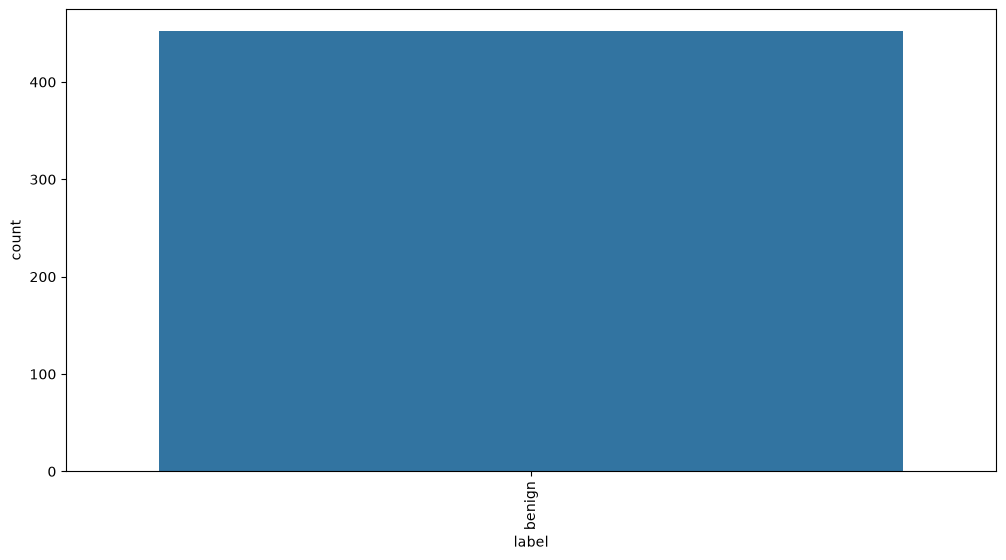

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df['label']
)

plt.xticks(rotation=90)
plt.show()

In [20]:
df['id.orig_h'].value_counts().head(10)

id.orig_h
192.168.1.132    452
Name: count, dtype: int64

In [21]:
df['id.resp_h'].value_counts().head(10)

id.resp_h
192.168.1.1        193
2.16.60.82          47
2.16.60.139         39
216.239.35.12       27
216.239.35.4        26
216.239.35.8        26
216.239.35.0        25
52.215.95.120       22
52.209.221.67       21
239.255.255.250     13
Name: count, dtype: int64

In [22]:
df['proto'].value_counts()

proto
udp    310
tcp    142
Name: count, dtype: int64

<Axes: xlabel='duration', ylabel='Count'>

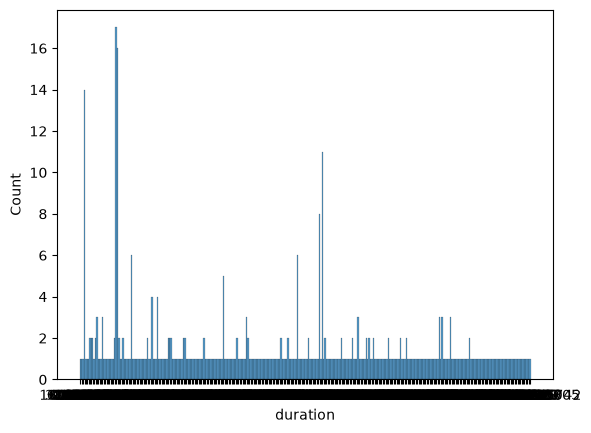

In [23]:
sns.histplot(
    df['duration']
)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
numeric_cols = [
    'duration',
    'orig_bytes',
    'resp_bytes',
    'orig_pkts',
    'resp_pkts'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [26]:
df[numeric_cols].describe()

,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts
count,451.000000,4.510000e+02,451.000000,452.000000,452.000000
mean,348.162228,6.638384e+03,296.423503,29.610619,7.805310
std,4970.477965,1.201943e+05,1152.304410,412.030448,125.368803
min,0.000479,0.000000e+00,0.000000,1.000000,0.000000
25%,0.007997,3.400000e+01,48.000000,1.000000,1.000000
50%,0.054699,3.700000e+01,100.000000,1.000000,1.000000
75%,0.114305,4.800000e+01,297.000000,4.000000,2.000000
max,78840.329305,2.550936e+06,22995.000000,8124.000000,2667.000000


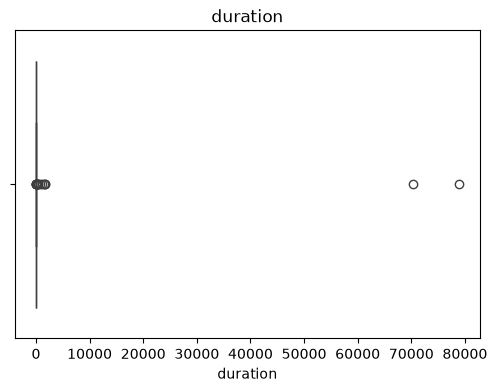

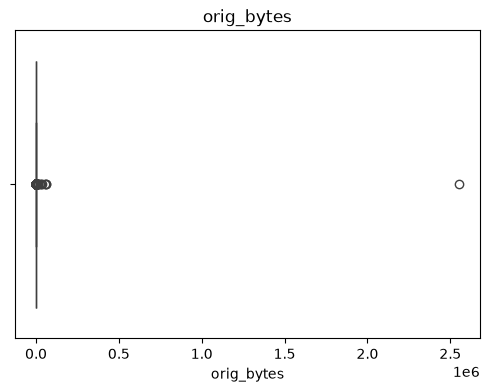

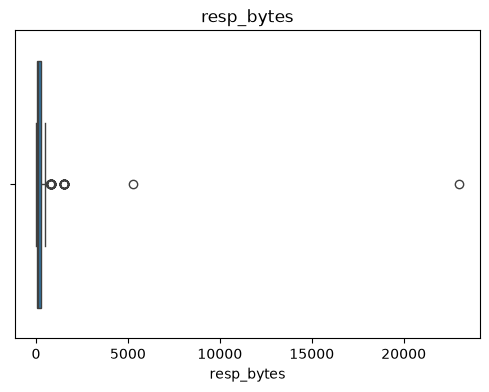

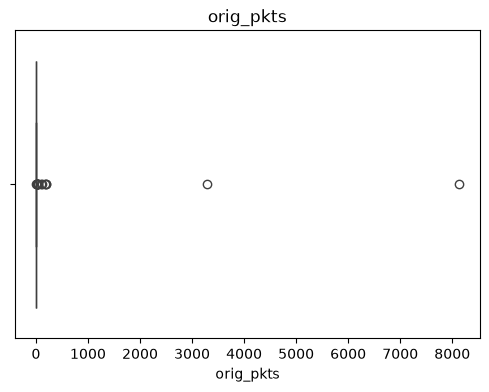

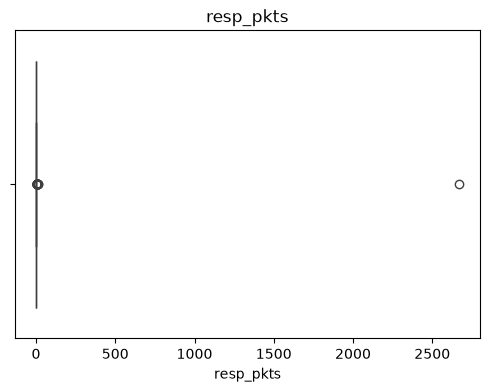

In [27]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

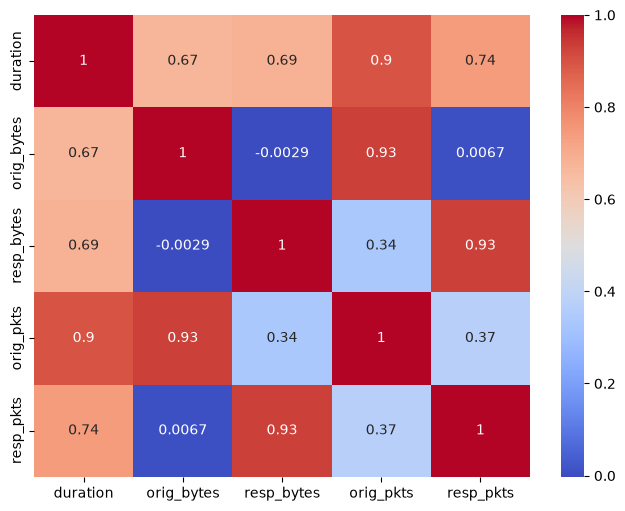

In [28]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

The correlation analysis reveals strong positive relationships between packet counts and byte counts in the same communication direction (orig_bytes–orig_pkts: 0.93 and resp_bytes–resp_pkts: 0.93). Connection duration is also highly correlated with packet counts, particularly orig_pkts (0.90), indicating that longer network sessions tend to involve more packet exchanges. However, cross-direction features such as orig_bytes and resp_bytes show negligible correlation, suggesting independent behavior between transmitted and received traffic volumes.

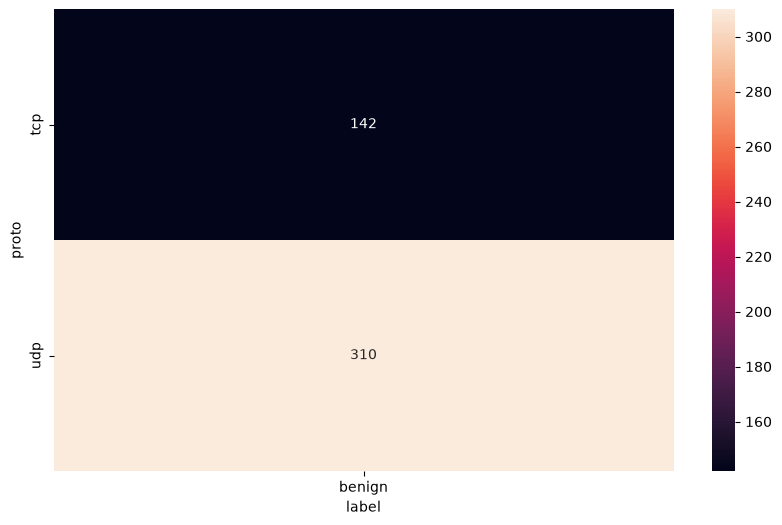

In [29]:
pd.crosstab(
    df['proto'],
    df['label']
)
plt.figure(figsize=(10,6))

sns.heatmap(
    pd.crosstab(
        df['proto'],
        df['label']
    ),
    annot=True,
    fmt='d'
)

plt.show()

In [30]:
pd.crosstab(
    df['conn_state'],
    df['label']
)

label,benign
conn_state,
OTH,1
RSTR,1
S0,14
SF,436


<Axes: xlabel='id.orig_h'>

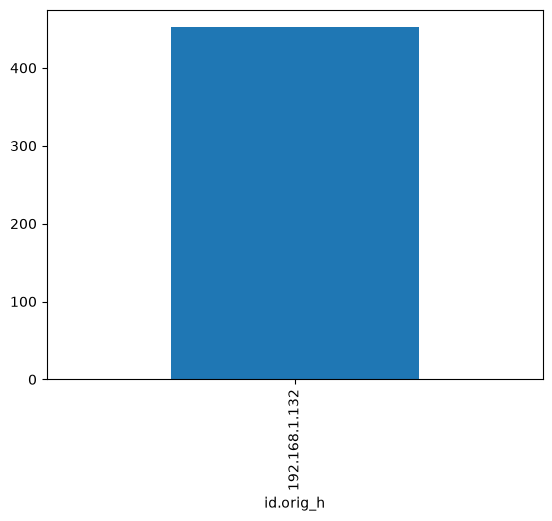

In [31]:
df['id.orig_h'].value_counts().head(10)
df['id.orig_h'].value_counts().head(10).plot(
    kind='bar'
)

In [32]:
df['id.orig_h'].value_counts().head(10)

id.orig_h
192.168.1.132    452
Name: count, dtype: int64

<Axes: xlabel='id.orig_h'>

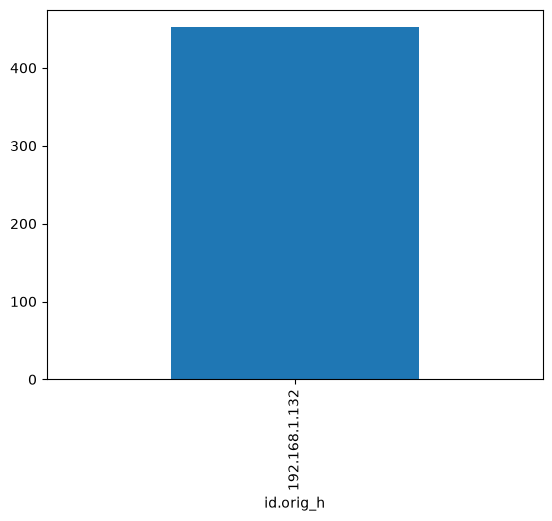

In [33]:
df['id.orig_h'].value_counts().head(10).plot(
    kind='bar'
)